# Assuming all choices are random

Best pair to pick: ([17, 1], [73, 4])
Best expected total profit: 265557.24


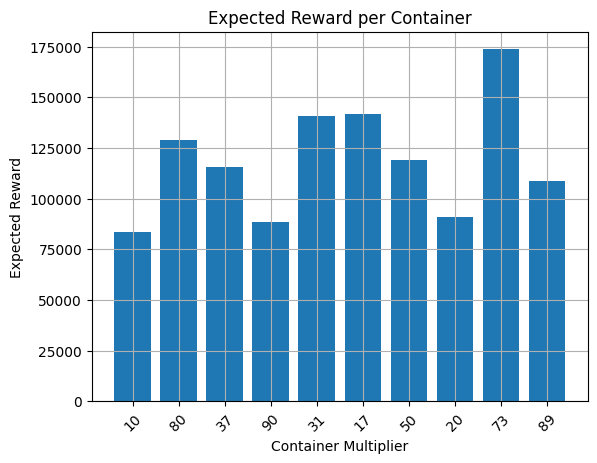

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

coins = 10000
data = [[10, 1], [80, 6], [37, 3], [90, 10], [31, 2], [17, 1], [50, 4], [20, 2], [73, 4], [89, 8]]

def choose():
    return np.random.permutation(10)[:2]

def simulate(trials=10000, second_pick_cost=50000):
    picks = np.zeros(10)

    for _ in range(trials):
        first, second = choose()
        picks[first] += 1
        picks[second] += 1

    expected_rewards = []
    for i, (multiplier, inhabitants) in enumerate(data):
        pick_fraction = picks[i] / trials
        divisor = inhabitants + pick_fraction
        reward = (coins * multiplier) / divisor
        expected_rewards.append(reward)

    best_pair = None
    best_profit = -float('inf')

    for i in range(10):
        for j in range(10):
            if i == j:
                continue
            profit = expected_rewards[i] + expected_rewards[j] - second_pick_cost
            if profit > best_profit:
                best_profit = profit
                best_pair = (data[i], data[j])


    return {
        "pick_frequencies": picks,
        "expected_rewards": expected_rewards,
        "best_pair": best_pair,
        "best_expected_total_profit": best_profit
    }

results = simulate()
print(f"Best pair to pick: {results['best_pair']}")
print(f"Best expected total profit: {results['best_expected_total_profit']:.2f}")

multipliers = [str(d[0]) for d in data]
plt.bar(multipliers, results["expected_rewards"])
plt.xticks(multipliers, rotation=45)
plt.xlabel("Container Multiplier")
plt.ylabel("Expected Reward")
plt.title("Expected Reward per Container")
plt.grid(True)
plt.show()


# Defining different types of players

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

coins = 10000
data = [[10, 1], [80, 6], [37, 3], [90, 10], [31, 2],
        [17, 1], [50, 4], [20, 2], [73, 4], [89, 8]]

def softmax(x, temperature=1.0):
    x = x / temperature
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()

def get_probs(strategy):
    if strategy == "greedy":
        scores = np.array([m for m, _ in data])
    elif strategy == "cautious":
        scores = np.array([1 / (inh + 1) for _, inh in data])
    elif strategy == "rational":
        scores = np.array([m / (inh + 1) for m, inh in data])
        return softmax(scores, temperature=0.8)
    else:  # random
        return np.ones(10) / 10
    return scores / scores.sum()

def choose(strategy):
    p = get_probs(strategy)
    return np.random.choice(range(10), size=2, replace=False, p=p)

def simulate(strategy="random", trials=10000, second_pick_cost=50000):
    picks = np.zeros(10)

    for _ in range(trials):
        first, second = choose(strategy)
        picks[first] += 1
        picks[second] += 1

    total_picks = np.sum(picks)

    expected_rewards = []
    for i, (multiplier, inhabitants) in enumerate(data):
        pick_fraction = picks[i] / total_picks
        divisor = inhabitants + pick_fraction
        reward = (coins * multiplier) / divisor
        expected_rewards.append(reward)

    best_pair = None
    best_profit = -float('inf')
    
    for i in range(10):
        for j in range(10):
            if i == j:
                continue
            profit = expected_rewards[i] + expected_rewards[j] - second_pick_cost
            if profit > best_profit:
                best_profit = profit
                best_pair = (data[i], data[j])

    return {
        "pick_frequencies": picks,
        "expected_rewards": expected_rewards,
        "best_pair": best_pair,
        "best_expected_total_profit": best_profit
    }

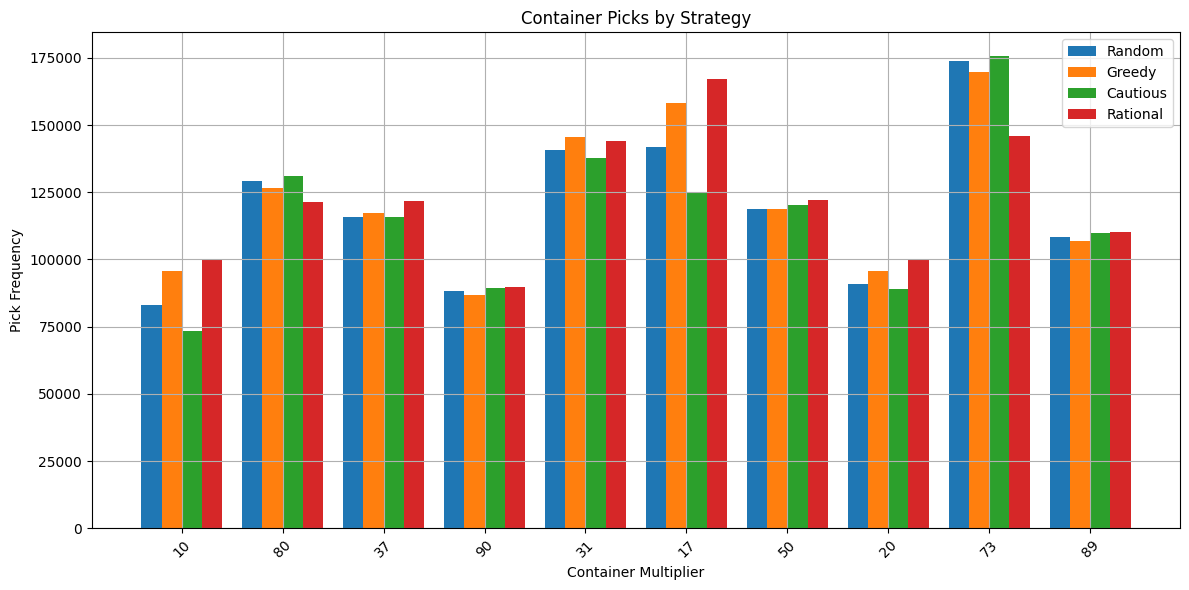

In [63]:
# Simulate for all player types
strategies = ["random", "greedy", "cautious", "rational"]
results = {s: simulate(strategy=s) for s in strategies}

# # Plot: Expected Reward per Container (for Rational player)
# multipliers = [str(d[0]) for d in data]
# plt.figure(figsize=(10, 6))
# plt.bar(multipliers, results["rational"]["expected_rewards"], color='green')
# plt.xticks(multipliers, rotation=45)
# plt.xlabel("Container Multiplier")
# plt.ylabel("Expected Reward")
# plt.title("Expected Reward per Container (Rational Player)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# Plot: Pick Frequencies by Player Type
plt.figure(figsize=(12, 6))
bar_width = 0.2
x = np.arange(10)
for i, s in enumerate(strategies):
    plt.bar(x + i * bar_width, results[s]["expected_rewards"], width=bar_width, label=s.title())

plt.xticks(x + bar_width * 1.5, multipliers, rotation=45)
plt.xlabel("Container Multiplier")
plt.ylabel("Pick Frequency")
plt.title("Container Picks by Strategy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
